## Desafio 2 da Trilha de Visão Computacional

### Instalação e Importação da Biblioteca

In [1]:
!pip install opencv-python matplotlib imutils tqdm scikit-learn

In [2]:
import cv2
import matplotlib.pyplot as plt
import os
import glob
import pickle
import numpy as np
import imutils
from tqdm.notebook import tqdm

### Conferir a Estrutura de Pastas

In [10]:
print("Pasta atual:", os.getcwd())
print()

for pessoa in sorted(os.listdir("dataset")):
    caminho = os.path.join("dataset", pessoa)
    if os.path.isdir(caminho):
        n_fotos = len([f for f in os.listdir(caminho) if not f.startswith(".")])
        print(f"dataset/{pessoa}: {n_fotos} foto(s)")

n_teste = len([f for f in os.listdir("test") if not f.startswith(".")])
print(f"\ntest/: {n_teste} foto(s)")

assert os.path.exists("face_detection_model/deploy.prototxt"), "deploy.prototxt não encontrado — confira a pasta face_detection_model/"
assert os.path.exists("face_detection_model/res10_300x300_ssd_iter_140000.caffemodel"), "caffemodel não encontrado — confira a pasta face_detection_model/"
assert os.path.exists("openface_nn4_small2_v1.t7"), "openface_nn4_small2_v1.t7 não encontrado na pasta raiz do notebook"
print("\nTodos os arquivos de modelo foram encontrados.")

Pasta atual: C:\Users\jones\Downloads\Desafio_gabaritado\Resolução 01\Desafios\Ex02

dataset/pessoa_1: 7 foto(s)
dataset/pessoa_2: 7 foto(s)
dataset/pessoa_3: 7 foto(s)

test/: 3 foto(s)

Todos os arquivos de modelo foram encontrados.


### Carregar os Modelos

In [11]:
detector = cv2.dnn.readNetFromCaffe(
    "face_detection_model/deploy.prototxt",
    "face_detection_model/res10_300x300_ssd_iter_140000.caffemodel"
)

embedder = cv2.dnn.readNetFromTorch("openface_nn4_small2_v1.t7")

print("Modelos carregados com sucesso.")

Modelos carregados com sucesso.


### Funções Reutilizáveis de Detecção e Extração de Embedding

In [12]:
def detectar_rostos(imagem, confianca_minima=0.5, tamanho_minimo=20):
    """Detecta todos os rostos em uma imagem usando o detector SSD (Caffe).

    Retorna uma lista de dicionários, um por rosto encontrado, com:
      - 'caixa': (startX, startY, endX, endY)
      - 'confianca': confiança da detecção (0 a 1)
      - 'rosto': recorte da imagem (array numpy) só com o rosto
    """
    (h, w) = imagem.shape[:2]

    blob = cv2.dnn.blobFromImage(
        cv2.resize(imagem, (300, 300)), 1.0, (300, 300),
        (104.0, 177.0, 123.0), swapRB=False, crop=False
    )
    detector.setInput(blob)
    deteccoes = detector.forward()

    resultados = []
    for i in range(deteccoes.shape[2]):
        confianca = deteccoes[0, 0, i, 2]
        if confianca < confianca_minima:
            continue

        caixa = deteccoes[0, 0, i, 3:7] * np.array([w, h, w, h])
        (startX, startY, endX, endY) = caixa.astype("int")

        # Garante que a caixa está dentro dos limites da imagem
        startX, startY = max(0, startX), max(0, startY)
        endX, endY = min(w, endX), min(h, endY)

        rosto = imagem[startY:endY, startX:endX]
        (altura_rosto, largura_rosto) = rosto.shape[:2]

        if largura_rosto < tamanho_minimo or altura_rosto < tamanho_minimo:
            continue

        resultados.append({
            "caixa": (startX, startY, endX, endY),
            "confianca": float(confianca),
            "rosto": rosto,
        })

    return resultados


def extrair_embedding(rosto_recortado):
    """Recebe o recorte de um rosto e devolve o vetor de embedding (128 posições)."""
    blob_rosto = cv2.dnn.blobFromImage(
        rosto_recortado, 1.0 / 255, (96, 96), (0, 0, 0), swapRB=True, crop=False
    )
    embedder.setInput(blob_rosto)
    vetor = embedder.forward().flatten()

    # Normaliza o vetor para comprimento 1 (necessário para usar similaridade de cosseno depois)
    norma = np.linalg.norm(vetor)
    if norma > 0:
        vetor = vetor / norma

    return vetor

### Processar a Base de Dados (Dataset)

In [13]:
embeddings_por_pessoa = {}  # nome da pessoa -> lista de vetores de embedding

caminhos_dataset = glob.glob(os.path.join("dataset", "*", "*"))
caminhos_dataset = [p for p in caminhos_dataset if not os.path.basename(p).startswith(".")]

for caminho in tqdm(caminhos_dataset):
    nome_pessoa = os.path.basename(os.path.dirname(caminho))

    imagem = cv2.imread(caminho)
    if imagem is None:
        print(f"Aviso: não consegui ler {caminho}, pulando.")
        continue

    imagem = imutils.resize(imagem, width=600)

    rostos = detectar_rostos(imagem)
    if len(rostos) == 0:
        print(f"Aviso: nenhum rosto encontrado em {caminho}, pulando.")
        continue

    # Assumindo 1 rosto por foto de treino: pega o de maior confiança
    melhor_rosto = max(rostos, key=lambda r: r["confianca"])

    vetor = extrair_embedding(melhor_rosto["rosto"])

    embeddings_por_pessoa.setdefault(nome_pessoa, []).append(vetor)

for pessoa, vetores in embeddings_por_pessoa.items():
    print(f"{pessoa}: {len(vetores)} embedding(s) extraído(s)")

  0%|          | 0/21 [00:00<?, ?it/s]

pessoa_1: 7 embedding(s) extraído(s)
pessoa_2: 7 embedding(s) extraído(s)
pessoa_3: 7 embedding(s) extraído(s)


In [14]:
# Calcula o centróide (vetor médio, renormalizado) de cada pessoa
centroides = {}

for pessoa, vetores in embeddings_por_pessoa.items():
    media = np.mean(vetores, axis=0)
    norma = np.linalg.norm(media)
    centroides[pessoa] = media / norma if norma > 0 else media

os.makedirs("output", exist_ok=True)
with open("output/centroides.pickle", "wb") as f:
    pickle.dump(centroides, f)

print("Centróides calculados e salvos em output/centroides.pickle:")
for pessoa in centroides:
    print(" -", pessoa)

Centróides calculados e salvos em output/centroides.pickle:
 - pessoa_1
 - pessoa_2
 - pessoa_3


### Reconhecer um Rosto por Similaridade de Cosseno

In [15]:
def reconhecer_rosto(vetor, centroides, limiar=0.5):
    """Compara o vetor de um rosto com os centróides de cada pessoa.

    Retorna (nome, similaridade). Se a melhor similaridade for menor que o limiar,
    retorna ("Desconhecido", similaridade).
    """
    melhor_nome = None
    melhor_similaridade = -1.0

    for nome, centroide in centroides.items():
        similaridade = float(np.dot(vetor, centroide))  # vetores já normalizados -> dot = cosseno
        if similaridade > melhor_similaridade:
            melhor_similaridade = similaridade
            melhor_nome = nome

    if melhor_similaridade < limiar:
        return "Desconhecido", melhor_similaridade

    return melhor_nome, melhor_similaridade

### Testar em Todas as Imagens da Pasta `test/`

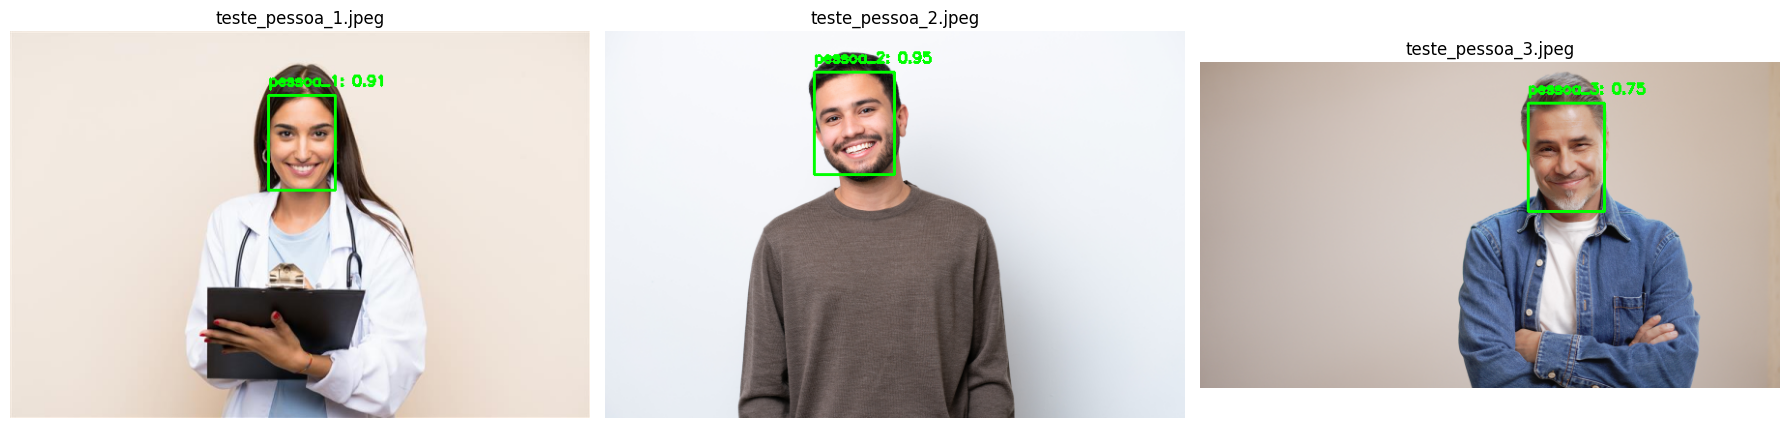

In [16]:
LIMIAR_RECONHECIMENTO = 0.5  # ajuste conforme a quantidade/qualidade das fotos do dataset

caminhos_teste = sorted(glob.glob(os.path.join("test", "*")))
caminhos_teste = [p for p in caminhos_teste if not os.path.basename(p).startswith(".")]

resultados_teste = []  # vai guardar (nome_arquivo, imagem_anotada)

for caminho in caminhos_teste:
    imagem = cv2.imread(caminho)
    if imagem is None:
        print(f"Aviso: não consegui ler {caminho}, pulando.")
        continue

    imagem = imutils.resize(imagem, width=600)
    rostos = detectar_rostos(imagem)

    for rosto_info in rostos:
        (startX, startY, endX, endY) = rosto_info["caixa"]
        vetor = extrair_embedding(rosto_info["rosto"])
        nome, similaridade = reconhecer_rosto(vetor, centroides, limiar=LIMIAR_RECONHECIMENTO)

        cor = (0, 0, 255) if nome == "Desconhecido" else (0, 255, 0)
        texto = f"{nome}: {similaridade:.2f}"
        y_texto = startY - 10 if startY - 10 > 10 else startY + 10

        cv2.rectangle(imagem, (startX, startY), (endX, endY), cor, 2)
        cv2.putText(imagem, texto, (startX, y_texto),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, cor, 2)

    resultados_teste.append((os.path.basename(caminho), cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)))

# Mostra tudo em um grid
n = len(resultados_teste)
colunas = min(3, n) if n > 0 else 1
linhas = (n + colunas - 1) // colunas if n > 0 else 1

fig, axs = plt.subplots(linhas, colunas, figsize=(6 * colunas, 5 * linhas))
axs = np.array(axs).reshape(-1) if n > 1 else [axs]

for ax, (nome_arquivo, img) in zip(axs, resultados_teste):
    ax.imshow(img)
    ax.set_title(nome_arquivo)
    ax.axis("off")

for ax in axs[len(resultados_teste):]:
    ax.axis("off")

plt.tight_layout()
plt.show()